In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import weibull_min
import json
import math
from io import StringIO


In [47]:
# load polar
s826_polar_text = """
alpha,Cl,Cd
-9.000,-0.3176,0.08270
-8.750,-0.3161,0.07273
-8.500,-0.3252,0.06502
-8.250,-0.3274,0.05806
-8.000,-0.3218,0.05208
-7.750,-0.2984,0.04653
-7.500,-0.2989,0.03956
-7.250,-0.2695,0.03649
-7.000,-0.2360,0.03348
-6.750,-0.2182,0.03109
-6.500,-0.1823,0.02080
-6.250,-0.1474,0.01867
-6.000,-0.1243,0.01705
-5.750,-0.0910,0.01562
-5.500,-0.0539,0.01439
-5.250,-0.0266,0.01350
-5.000,0.0125,0.01218
-4.750,0.0480,0.01133
-4.500,0.0899,0.01043
-4.250,0.1329,0.00970
-4.000,0.1896,0.00778
-3.750,0.2353,0.00769
-3.500,0.2769,0.00771
-3.250,0.3125,0.00787
-3.000,0.3426,0.00804
-2.750,0.3716,0.00820
-2.500,0.3988,0.00834
-2.250,0.4259,0.00852
-2.000,0.4530,0.00864
-1.750,0.4798,0.00873
-1.500,0.5068,0.00886
-1.250,0.5342,0.00893
-1.000,0.5618,0.00900
-0.750,0.5895,0.00909
-0.500,0.6170,0.00911
-0.250,0.6445,0.00917
0.000,0.6721,0.00925
0.250,0.7000,0.00934
0.500,0.7279,0.00942
0.750,0.7562,0.00954
1.000,0.7839,0.00955
1.250,0.8117,0.00964
1.500,0.8399,0.00974
1.750,0.8678,0.00981
2.000,0.8959,0.00994
2.250,0.9236,0.01000
2.500,0.9506,0.01006
2.750,0.9780,0.01020
3.000,1.0041,0.01025
3.250,1.0310,0.01038
3.500,1.0571,0.01041
3.750,1.0838,0.01055
4.000,1.1099,0.01062
4.250,1.1361,0.01073
4.500,1.1622,0.01080
4.750,1.1878,0.01092
5.000,1.2127,0.01105
5.250,1.2379,0.01116
5.500,1.2623,0.01124
6.000,1.3099,0.01151
6.250,1.3323,0.01169
6.500,1.3530,0.01193
6.750,1.3695,0.01237
7.000,1.3771,0.01337
7.250,1.3843,0.01442
7.500,1.3934,0.01541
7.750,1.4033,0.01635
8.000,1.4134,0.01727
8.250,1.4234,0.01819
8.500,1.4335,0.01911
8.750,1.4449,0.01996
9.000,1.4561,0.02082
9.250,1.4667,0.02174
9.500,1.4766,0.02271
9.750,1.4858,0.02375
10.000,1.4950,0.02481
10.250,1.5047,0.02584
10.500,1.5061,0.02664
11.000,1.5174,0.02976
11.500,1.5249,0.03348
12.000,1.5281,0.03801
12.500,1.5260,0.04352
13.000,1.5283,0.04901
13.500,1.5224,0.05588
14.000,1.5058,0.06468
14.500,1.5017,0.07230
15.000,1.4947,0.08070
15.500,1.4855,0.08985
16.000,1.4749,0.09960
16.500,1.4624,0.11007
17.000,1.4480,0.12129
17.500,1.4310,0.13353
18.000,1.4124,0.14675
18.500,1.3913,0.16121
19.000,1.3701,0.17661
19.250,1.3582,0.18507
"""
df = pd.read_csv(StringIO(s826_polar_text))
alpha_arr = df['alpha'].values
Cl_arr = df['Cl'].values
Cd_arr = df['Cd'].values
def lookup_polar(alpha_deg):
    Cl = np.interp(alpha_deg, alpha_arr, Cl_arr, left=Cl_arr[0], right=Cl_arr[-1])
    Cd = np.interp(alpha_deg, alpha_arr, Cd_arr, left=Cd_arr[0], right=Cd_arr[-1])
    return float(Cl), float(Cd)
print("Loaded S826 polar with", len(alpha_arr), "points.")


Loaded S826 polar with 96 points.


In [48]:
# BEM solver
def prandtl_tip_loss(B, r, R, phi):
    f = (B/2.0) * (R - r) / (r * np.sin(phi) + 1e-12)
    expf = np.exp(-f)
    F = (2/np.pi) * np.arccos(np.clip(expf, 0.0, 1.0))
    return np.clip(F, 1e-6, 1.0)

def bem_power_iterative(chords, twists_deg, R, rho, V, omega_rpm, B=3, max_iter=100, tol=1e-4, airfoil_lookup=lookup_polar):
    N = len(chords)
    r = np.linspace(R/(2*N), R - R/(2*N), N)
    dr = R / N
    omega = omega_rpm * 2*np.pi/60.0
    total_power = 0.0
    for i in range(N):
        ri = r[i]
        c = chords[i]
        twist = twists_deg[i]
        a = 0.3
        a_prime = 0.0
        for itr in range(max_iter):
            Vax = V * (1 - a)
            Vtan = omega * ri * (1 + a_prime)
            Vrel = np.sqrt(Vax**2 + Vtan**2)
            phi = np.arctan2(Vax, Vtan + 1e-12)
            phi_deg = np.degrees(phi)
            alpha = phi_deg - twist
            Cl, Cd = airfoil_lookup(alpha)
            q = 0.5 * rho * Vrel**2
            L = q * c * Cl
            D = q * c * Cd
            Fn = L * np.cos(phi) + D * np.sin(phi)
            Ft = L * np.sin(phi) - D * np.cos(phi)
            sigma = (c * B) / (2 * np.pi * ri)
            F = prandtl_tip_loss(B, ri, R, phi)
            if F < 1e-6: F = 1e-6
            a_new = 1.0 / ( (4*F*np.sin(phi)**2) / (sigma * Cl * np.cos(phi)) + 1.0 )
            a_prime_new = 1.0 / ( (4*F*np.sin(phi)*np.cos(phi)) / (sigma * Cl) - 1.0 )
            a_new = np.clip(a_new, 0.0, 0.95)
            a_prime_new = np.clip(a_prime_new, -0.95, 0.95)
            if abs(a_new - a) < tol and abs(a_prime_new - a_prime) < tol:
                a, a_prime = a_new, a_prime_new
                break
            a, a_prime = 0.75*a + 0.25*a_new, 0.75*a_prime + 0.25*a_prime_new
        Vax = V * (1 - a)
        Vtan = omega * ri * (1 + a_prime)
        Vrel = np.sqrt(Vax**2 + Vtan**2)
        phi = np.arctan2(Vax, Vtan + 1e-12)
        phi_deg = np.degrees(phi)
        alpha = phi_deg - twist
        Cl, Cd = airfoil_lookup(alpha)
        q = 0.5 * rho * Vrel**2
        L = q * c * Cl
        D = q * c * Cd
        Ft = L * np.sin(phi) - D * np.cos(phi)
        dT = Ft * ri * dr
        total_power += dT * omega
    return total_power


In [49]:
# AEP calc
def compute_AEP(chords, twists_deg, R, rho, Vbins, weights, omega_for_V, bem_solver=bem_power_iterative):
    total = 0.0
    for V, w in zip(Vbins, weights):
        omega_rpm = omega_for_V(V)
        P = bem_solver(chords, twists_deg, R, rho, V, omega_rpm)
        total += P * w
    return total * 8760.0


In [50]:
# setup
R = 16.0
rho = 1.225
N = 8
baseline_chords = np.linspace(3.0, 0.5, N)
baseline_twists = np.linspace(14.0, 0.0, N)
Vbins = np.linspace(3.0, 25.0, 23)
k_weib, c_weib = 2.0, 7.0
weights = weibull_min(c=k_weib, scale=c_weib).pdf(Vbins)
weights = weights / weights.sum()
TSR_target = 7.0
def omega_for_V(V):
    omega_rad_s = TSR_target * V / R
    return omega_rad_s * 60.0 / (2*np.pi)


In [51]:
# baseline AEP
baseline_AEP = compute_AEP(baseline_chords, baseline_twists, R, rho, Vbins, weights, omega_for_V)
print(f"Baseline AEP ≈ {baseline_AEP/1e6:.3f} MWh/year")


Baseline AEP ≈ 101.682 MWh/year


In [52]:
# optimize
def pack_x(chords, twists):
    return np.concatenate([chords, twists])
def unpack_x(x):
    n = len(x)//2
    return x[:n], x[n:]
def mass_proxy(chords, factor=1.0):
    return np.sum(chords)
def smoothness_penalty(arr, limit):
    sec = np.diff(arr, n=2)
    return np.sum(np.maximum(0, np.abs(sec) - limit)**2)
def objective_x(x):
    chords, twists = unpack_x(x)
    aep = compute_AEP(chords, twists, R, rho, Vbins, weights, omega_for_V)
    pen = 0.0
    pen += 1e3 * smoothness_penalty(chords, 1.0)
    pen += 1e3 * smoothness_penalty(twists, 5.0)
    return -aep + pen
bnds = [(0.2, 5.0)] * N + [(-5.0, 30.0)] * N
Mmax = mass_proxy(baseline_chords) * 1.05
cons = ({ 'type': 'ineq', 'fun' : lambda x: Mmax - mass_proxy(unpack_x(x)[0]) })
x0 = pack_x(baseline_chords, baseline_twists)
res = minimize(objective_x, x0, method='SLSQP', bounds=bnds, constraints=cons, options={'maxiter':300, 'ftol':1e-3, 'disp': True})
opt_chords, opt_twists = unpack_x(res.x)
opt_AEP = compute_AEP(opt_chords, opt_twists, R, rho, Vbins, weights, omega_for_V)
print(f"Optimized AEP ≈ {opt_AEP/1e6:.3f} MWh/year  (improvement {(opt_AEP-baseline_AEP)/baseline_AEP*100:.2f}%)")


Inequality constraints incompatible    (Exit mode 4)
            Current function value: -101682458.33763556
            Iterations: 1
            Function evaluations: 17
            Gradient evaluations: 1
Optimized AEP ≈ 101.682 MWh/year  (improvement 0.00%)


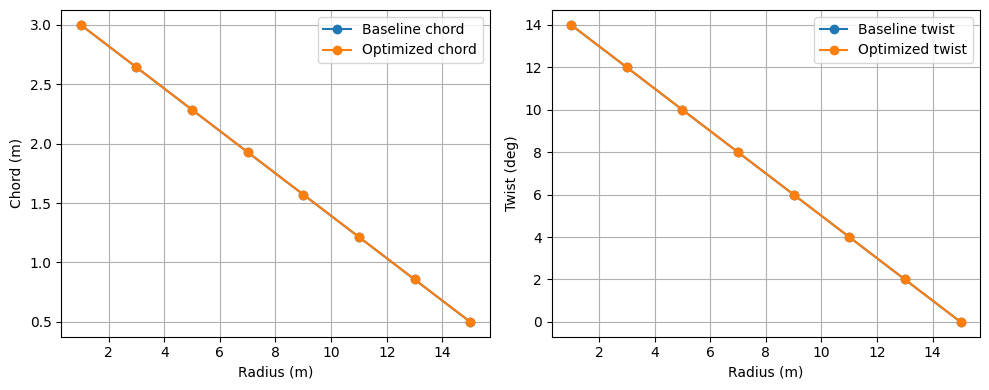

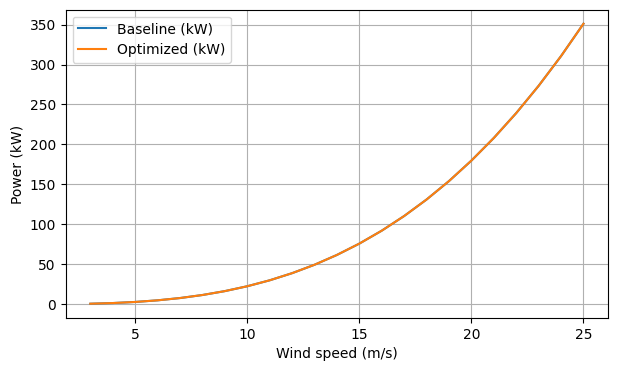

In [53]:
# plots
r = np.linspace(R/(2*N), R - R/(2*N), N)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(r, baseline_chords, 'o-', label='Baseline chord')
plt.plot(r, opt_chords, 'o-', label='Optimized chord')
plt.xlabel('Radius (m)'); plt.ylabel('Chord (m)'); plt.grid(True); plt.legend()
plt.subplot(1,2,2)
plt.plot(r, baseline_twists, 'o-', label='Baseline twist')
plt.plot(r, opt_twists, 'o-', label='Optimized twist')
plt.xlabel('Radius (m)'); plt.ylabel('Twist (deg)'); plt.grid(True); plt.legend()
plt.tight_layout(); plt.show()
def power_curve(chords, twists):
    P = []
    for V in Vbins:
        P.append(bem_power_iterative(chords, twists, R, rho, V, omega_for_V(V)))
    return np.array(P)
P_baseline = power_curve(baseline_chords, baseline_twists)
P_opt = power_curve(opt_chords, opt_twists)
plt.figure(figsize=(7,4))
plt.plot(Vbins, P_baseline/1e3, label='Baseline (kW)')
plt.plot(Vbins, P_opt/1e3, label='Optimized (kW)')
plt.xlabel('Wind speed (m/s)'); plt.ylabel('Power (kW)'); plt.grid(True); plt.legend(); plt.show()


In [54]:
# save
out = {
    "R": R,
    "N": N,
    "baseline_chords": baseline_chords.tolist(),
    "baseline_twists": baseline_twists.tolist(),
    "opt_chords": opt_chords.tolist(),
    "opt_twists": opt_twists.tolist(),
    "baseline_AEP_Wh": float(baseline_AEP),
    "opt_AEP_Wh": float(opt_AEP)
}
with open("results.json", "w") as f:
    json.dump(out, f, indent=2)
print("Saved results.json")


Saved results.json
